# Causal Discovery on Deep Learning Outputs (8 Segments)

Similar to the 4-segment analysis, this notebook analyzes the causal relationships between hidden states of our RNN model predicting protein-to-RNA ratios (PTRs). Evaluating finer granularities, the RNN processing the coding sequence (CDS) had its output divided into **8 equal segments** to be used as variables for causal discovery methods.

In [4]:
import io

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from causallearn.utils.GraphUtils import GraphUtils


In [ ]:
filepath = '../data/processed/rnn_hidden_states_pooled.csv'

In [10]:
all_columns = ['seg1','seg2','seg3','seg4','seg5','seg6','seg7','seg8','y_pred','y','len','tissue']
rnn_data_all = pd.read_csv(filepath, names=all_columns)
rnn_data_all

,seg1,seg2,seg3,seg4,seg5,seg6,seg7,seg8,y_pred,y,len,tissue
0,0.23858,-0.03204,-0.12674,0.13457,0.58075,1.0,1935.0,20.0,NaN,NaN,NaN,NaN
1,-0.44640,0.18358,0.13677,-0.09148,0.35752,1.0,4320.0,10.0,NaN,NaN,NaN,NaN
2,0.17260,-0.19898,-0.22365,-0.06009,0.56335,1.0,1719.0,22.0,NaN,NaN,NaN,NaN
3,0.18007,-0.15868,-0.08679,0.11612,0.56016,0.0,765.0,7.0,NaN,NaN,NaN,NaN
4,0.12154,-0.12210,0.00373,0.17049,0.60807,1.0,4593.0,7.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19665,0.42271,-0.13956,-0.13820,-0.21124,0.40931,1.0,1074.0,27.0,NaN,NaN,NaN,NaN
19666,0.37526,-0.10260,-0.00290,-0.32103,0.31688,0.0,9525.0,27.0,NaN,NaN,NaN,NaN
19667,0.25110,0.01716,0.05445,-0.03515,0.47825,1.0,1095.0,23.0,NaN,NaN,NaN,NaN
19668,0.33399,-0.02515,-0.00321,-0.31321,0.28183,0.0,2625.0,12.0,NaN,NaN,NaN,NaN


In [4]:
columns = ['seg1','seg2','seg3','seg4','seg5','seg6','seg7','seg8','y_pred','len','tissue']
rnn_data = rnn_data_all[columns]
rnn_data

,seg1,seg2,seg3,seg4,seg5,seg6,seg7,seg8,y_pred,len,tissue
0,0.15428,0.56652,0.07214,-0.33255,-0.00150,0.02957,0.01565,-0.01010,0.41374,4230.0,12.0
1,0.05433,0.35792,0.24319,-0.08437,-0.00273,0.04449,-0.00503,0.00345,0.43023,807.0,4.0
2,0.06881,0.05883,0.54349,0.37835,0.00921,0.04516,0.00619,0.02343,0.80452,603.0,25.0
3,-0.07912,-0.05267,0.49633,0.23123,0.02145,0.01789,0.02341,0.01438,0.79409,540.0,11.0
4,0.10595,-0.17422,0.11392,-0.06826,0.02575,0.01844,0.01891,0.01389,0.46203,417.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...
19665,-0.05504,-0.19994,0.38601,0.13875,0.01860,0.03208,0.00950,0.02344,0.64096,1074.0,27.0
19666,0.04669,-0.27949,-0.26441,-0.47672,0.01379,0.02954,0.02164,0.01427,0.22233,9525.0,27.0
19667,-0.10378,0.25171,0.13445,-0.09009,-0.00625,-0.05686,-0.00792,-0.01673,0.37448,1095.0,23.0
19668,0.09845,0.33947,0.06643,-0.29181,-0.01740,-0.05223,-0.00025,-0.05275,0.37641,2625.0,12.0


---
# LiNGAM

LiNGAM (Linear Non-Gaussian Acyclic Model) assumes linearity in the data, non-Gaussian noise, acyclicity, and no latent common causes. 

We test both:
- **Direct LiNGAM**: Converges directly without needing parametric setup.
- **ICA LiNGAM**: Independent Component Analysis version, evaluated in the report to be the most consistent algorithm. It consistently assigns segments closer to the end of the CDS sequence (along with target elements) to the top of the causal cascade, separating tissue metadata towards the bottom.

### Direct LiNGAM

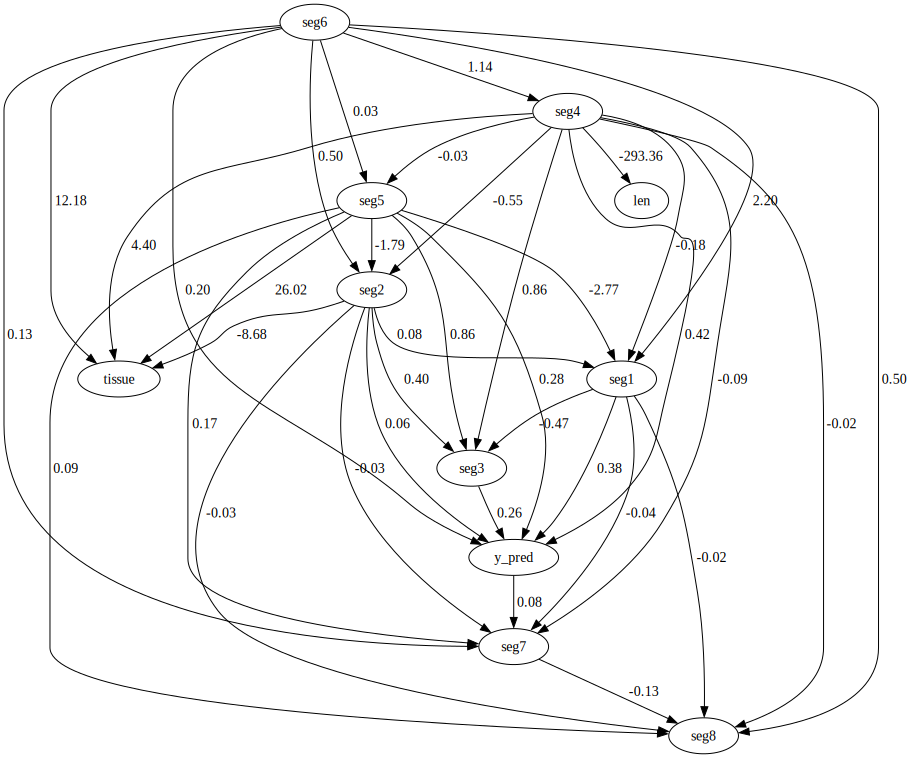

In [5]:
import lingam
from lingam.utils import make_dot,print_causal_directions, print_dagc, make_dot

model = lingam.DirectLiNGAM()
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

### ICA-LINGAM

In [ ]:
from causallearn.search.FCMBased import lingam
model = lingam.ICALiNGAM(max_iter=15000)
model.fit(rnn_data)

make_dot(model.adjacency_matrix_, labels=columns)

---
# FCI 

Fast Causal Inference (FCI) is a constraint-based method. It evaluates condition independence between factors. When run on the sequential segments across sequences, it predominantly uncovers common latent-cause relationships.

In [ ]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz

graph, edges = fci(rnn_data.to_numpy(), independence_test_method=fisherz, depth=3)

In [ ]:
pyd = GraphUtils.to_pydot(graph, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)


---
# GES

GES (Greedy Equivalence Search) relies on scoring distributions to search the graph space. Starting empty, it uses Bayesian scores to form the DAG. As discussed in the thesis, GES was less consistent than ICA LiNGAM across repeated segmentation experiments.

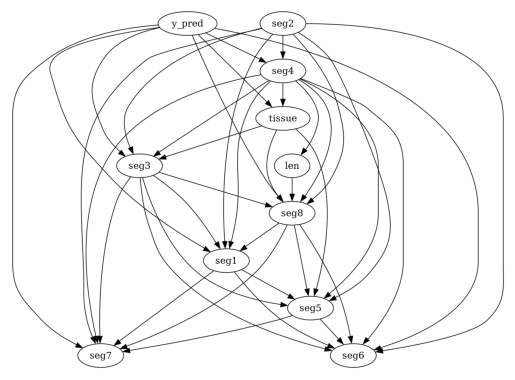

In [9]:
from causallearn.search.ScoreBased.GES import ges
from causallearn.score.LocalScoreFunction import local_score_cv_general

Record = ges(rnn_data)

pyd = GraphUtils.to_pydot(Record['G'], labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.axis('off')
plt.imshow(img)

---
# CGNN

Causal Generative Neural Networks (CGNN) construct continuous representations of variables. As observed during experimentation, CGNN struggled to converge accurately given the dimensionality differences in the sequences without a supplied skeletal graph.

In [1]:
import networkx as nx
from cdt.causality.graph import CGNN

obj = CGNN()
output = obj.predict(rnn_data[:100])   
nx.draw_networkx(output, font_size=8, with_labels=True)

/home/ttsonev/Desktop/BA/.venv/lib64/python3.13/site-packages/cdt/utils/io.py:44: SyntaxWarning: invalid escape sequence '\*'
  \**kwargs: parameters to be passed to pandas.read_csv
/home/ttsonev/Desktop/BA/.venv/lib64/python3.13/site-packages/cdt/utils/Settings.py:116: SyntaxWarning: invalid escape sequence '\*'
  1. \**kwargs for retrieving a single argument: ``get_default(argument_name=value)``.
No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.
invalid escape sequence '\*'
invalid escape sequence '\*'
invalid escape sequence '\*'
invalid escape sequence '\*'


NameError: name 'rnn_data' is not defined

---
# PC

The Peter-Clark (PC) constraint-based algorithm was attempted. As stated in the findings, PC often required extensive compute time (upward of several hours via GPU) and thus was unappealing for systematic runs across varying architectures.

In [ ]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

cg = pc(rnn_data.to_numpy(), 0.05, fisherz)
pyd = GraphUtils.to_pydot(cg.G, labels=columns)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)